In [ ]:
!pip install -q torch torchvision transformers accelerate qwen-vl-utils pillow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 20.2 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from PIL import Image

In [ ]:
model_name = "Qwen/Qwen2.5-VL-3B-Instruct"
processor = AutoProcessor.from_pretrained(model_name)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(model_name, torch_dtype=torch.float16, device_map="auto")

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

model.safetensors.index.json:   0%|          | 0.00/65.4k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving person_01.png to person_01.png


In [ ]:
uploaded.keys()

dict_keys(['person_01.png'])

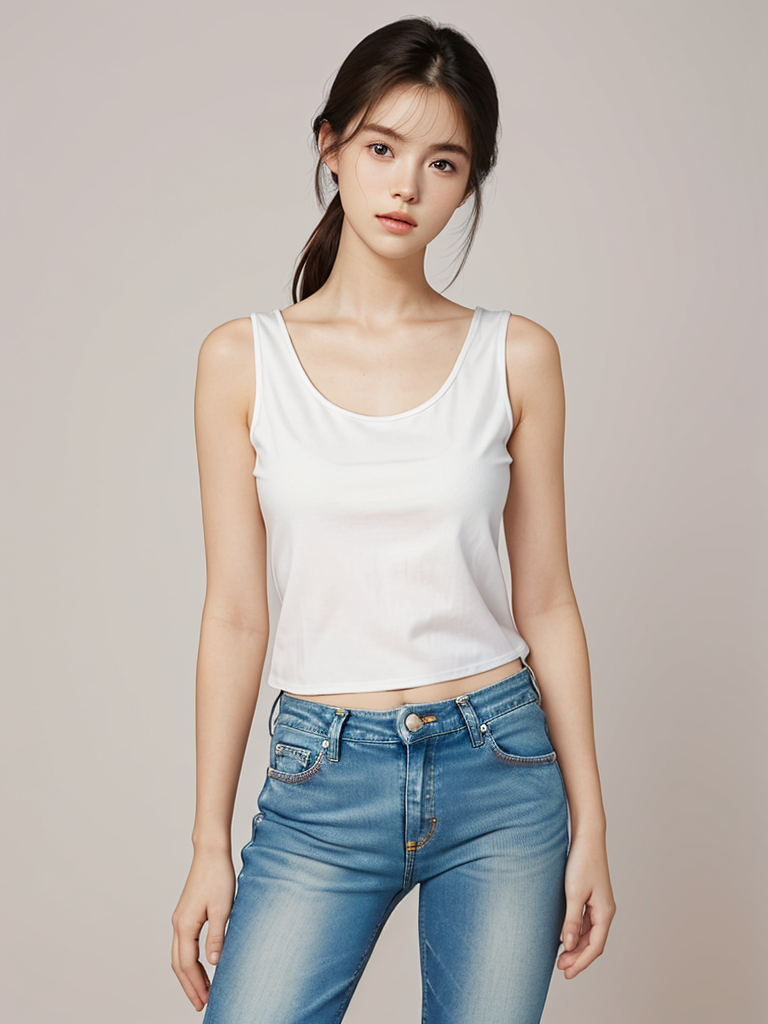

In [ ]:
image = Image.open("person_01.png")
display(image)

In [ ]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {
                "type": "text",
                "text": """
Analyze this person's clothing.

Return ONLY a JSON object with these fields:

{
  "gender": "",
  "upper_garment": "",
  "upper_color": "",
  "lower_garment": "",
  "lower_color": "",
  "sleeve_length": "",
  "neckline": "",
  "pattern": "",
  "accessories": []
}

Do not explain anything.
Return only valid JSON.
"""
            }
        ]
    }
]

In [ ]:
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=[text], images=[image], return_tensors="pt")
inputs = inputs.to(model.device)

In [ ]:
generated_ids = model.generate(**inputs, max_new_tokens=200)
generated_ids = generated_ids[:, inputs.input_ids.shape[1]:]
response = processor.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True)
print(response[0])

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer Qwen2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


```json
{
  "gender": "female",
  "upper_garment": "tank top",
  "upper_color": "white",
  "lower_garment": "jeans",
  "lower_color": "blue",
  "sleeve_length": "short",
  "neckline": "bodice",
  "pattern": "solid",
  "accessories": []
}
```


In [ ]:
import json
json_text = response[0]
json_text = json_text.replace("```json","").replace("```","").strip()
data = json.loads(json_text)

print(type(data))
print(data)

<class 'dict'>
{'gender': 'female', 'upper_garment': 'tank top', 'upper_color': 'white', 'lower_garment': 'jeans', 'lower_color': 'blue', 'sleeve_length': 'short', 'neckline': 'bodice', 'pattern': 'solid', 'accessories': []}


In [ ]:
with open("output.json","w") as f:
    json.dump(data, f, indent=4)
print("JSON saved successfully!")

JSON saved successfully!


In [ ]:
with open("output.json", "r") as f:
    print(f.read())

{
    "gender": "female",
    "upper_garment": "tank top",
    "upper_color": "white",
    "lower_garment": "jeans",
    "lower_color": "blue",
    "sleeve_length": "short",
    "neckline": "bodice",
    "pattern": "solid",
    "accessories": []
}


In [ ]:
import os

os.makedirs("AI_Virtual_TryOn/models", exist_ok=True)
os.makedirs("AI_Virtual_TryOn/utils", exist_ok=True)
os.makedirs("AI_Virtual_TryOn/outputs", exist_ok=True)

print("Project folders created successfully!")

Project folders created successfully!


In [ ]:
import shutil

shutil.move("output.json", "AI_Virtual_TryOn/outputs/output.json")

print("output.json moved successfully!")

output.json moved successfully!


In [ ]:
import os

for root, dirs, files in os.walk("AI_Virtual_TryOn"):
    level = root.replace("AI_Virtual_TryOn", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

AI_Virtual_TryOn/
    models/
    outputs/
        output.json
    utils/


In [ ]:
!pip install rembg onnxruntime
!pip install gdown

INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.1/46.1 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 39.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 121.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 101.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 123.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 MB 16.5 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2

In [ ]:
import os

for root, dirs, files in os.walk("AI_Virtual_TryOn"):
    level = root.replace("AI_Virtual_TryOn", "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")
    subindent = " " * 4 * (level + 1)
    for file in files:
        print(f"{subindent}{file}")

AI_Virtual_TryOn/
    models/
    outputs/
        output.json
    utils/


In [ ]:
!git clone https://github.com/GoGoDuck912/Self-Correction-Human-Parsing.git

Cloning into 'Self-Correction-Human-Parsing'...
remote: Enumerating objects: 722, done.
remote: Counting objects: 100% (174/174), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 722 (delta 74), reused 64 (delta 64), pack-reused 548 (from 2)
Receiving objects: 100% (722/722), 3.88 MiB | 11.90 MiB/s, done.
Resolving deltas: 100% (150/150), done.


In [ ]:
!ls

AI_Virtual_TryOn  person_01.png  sample_data  Self-Correction-Human-Parsing


In [ ]:
!ls Self-Correction-Human-Parsing

datasets	  evaluate.py	 modules    requirements.txt	 utils
demo		  LICENSE	 networks   simple_extractor.py
environment.yaml  mhp_extension  README.md  train.py


In [ ]:
!head -100 Self-Correction-Human-Parsing/README.md

# Self Correction for Human Parsing

![Python 3.6](https://img.shields.io/badge/python-3.6-green.svg)
[![License: MIT](https://img.shields.io/badge/License-MIT-green.svg)](https://opensource.org/licenses/MIT)

An out-of-box human parsing representation extractor.

Our solution ranks 1st for all human parsing tracks (including single, multiple and video) in the third LIP challenge!

![lip-visualization](./demo/lip-visualization.jpg) 

Features:
- [x] Out-of-box human parsing extractor for other downstream applications.
- [x] Pretrained model on three popular single person human parsing datasets.
- [x] Training and inferecne code.
- [x] Simple yet effective extension on multi-person and video human parsing tasks.

## Requirements

```
conda env create -f environment.yaml
conda activate schp
pip install -r requirements.txt
```

## Simple Out-of-Box Extractor

The easiest way to get started is to use our trained SCHP models on your own images to extract human parsing representations. Here 

In [ ]:
!ls Self-Correction-Human-Parsing/demo

demo_atr.png  demo.jpg	demo_lip.png  demo_pascal.png  lip-visualization.jpg


In [ ]:
!mkdir -p Self-Correction-Human-Parsing/checkpoints

!gdown 1k4dllHpu0bdx38J7H28rVVLpU-kOHmnH \
-O Self-Correction-Human-Parsing/checkpoints/exp-schp-201908261155-lip.pth

Downloading...
From (original): https://drive.google.com/uc?id=1k4dllHpu0bdx38J7H28rVVLpU-kOHmnH
From (redirected): https://drive.google.com/uc?id=1k4dllHpu0bdx38J7H28rVVLpU-kOHmnH&confirm=t&uuid=77b95a73-7a6d-40cb-a0ee-3b3013befc5d
To: /content/Self-Correction-Human-Parsing/checkpoints/exp-schp-201908261155-lip.pth
100% 267M/267M [00:08<00:00, 32.6MB/s]


In [ ]:
%cd Self-Correction-Human-Parsing

!pip install -r requirements.txt

/content/Self-Correction-Human-Parsing
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.9/88.9 MB 9.8 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 2
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 2
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
!pip install torch torchvision opencv-python pillow scipy tqdm yacs

In [ ]:
import cv2
print(cv2.version)

<module 'cv2.version' from '/usr/local/lib/python3.12/dist-packages/cv2/version.py'>


In [ ]:
import cv2
print(cv2.__version__)

4.13.0


In [ ]:
%cd /content/Self-Correction-Human-Parsing

!python simple_extractor.py --help

/content/Self-Correction-Human-Parsing
Traceback (most recent call last):
  File "/content/Self-Correction-Human-Parsing/simple_extractor.py", line 24, in <module>
    import networks
  File "/content/Self-Correction-Human-Parsing/networks/__init__.py", line 3, in <module>
    from networks.AugmentCE2P import resnet101
  File "/content/Self-Correction-Human-Parsing/networks/AugmentCE2P.py", line 21, in <module>
    from modules import InPlaceABNSync
  File "/content/Self-Correction-Human-Parsing/modules/__init__.py", line 1, in <module>
    from .bn import ABN, InPlaceABN, InPlaceABNSync
  File "/content/Self-Correction-Human-Parsing/modules/bn.py", line 10, in <module>
    from .functions import *
  File "/content/Self-Correction-Human-Parsing/modules/functions.py", line 10, in <module>
    _backend = load(name="inplace_abn",
               ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/cpp_extension.py", line 1818, in load
    return _jit_compile

In [ ]:
!pip install ninja

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 8.5 MB/s eta 0:00:00


In [ ]:
!ninja --version

1.13.0.git.kitware.jobserver-pipe-1


In [ ]:
%cd /content

/content


In [ ]:
!pip install transformers accelerate timm

In [ ]:
!pip install huggingface_hub
!pip install git+https://github.com/huggingface/transformers.git

  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-5ncd9nvg
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-5ncd9nvg
  Resolved https://github.com/huggingface/transformers.git to commit b6d5084fb4a5dd11e44005a5fa009e7943271090
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for transformers: filename=transformers-5.15.0.dev0-py3-none-any.whl size=12917428 sha256=c615135b76f79860dd9ad68a4d601c5774a3236cbd5233b9a09a0844116d2075
  Stored in directory: /tmp/pip-ephem-wheel-cache-vzpfgj1j/wheels/54/cb/3f/83103de5575c534436d6a4686686dead458238dfaf1147e98d
Successfully built transformers
  Attempting uninstall: transformers
    Found existing installation: transformers 5.13.1
    Uninstalling transformers-5.13.1:
      Successfully uninstalled transformers-5.13.1


In [ ]:
!git clone https://github.com/GoGoDuck912/SCHP-Human-Parsing.git

Cloning into 'SCHP-Human-Parsing'...
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
!pip install fashn-human-parser

In [ ]:
!python -c "from fashn_human_parser import FashnHumanParser; print('Installed successfully')"

Installed successfully


In [ ]:
from fashn_human_parser import FashnHumanParser

help(FashnHumanParser)

Help on class FashnHumanParser in module fashn_human_parser.parser:

class FashnHumanParser(builtins.object)
 |  FashnHumanParser(model_id: str = 'fashn-ai/fashn-human-parser', device: str = None)
 |
 |  Human parsing model that segments images into 18 semantic classes.
 |
 |  This class provides the exact preprocessing used during training for
 |  maximum accuracy. For quick experimentation, you can also use the
 |  HuggingFace pipeline API directly.
 |
 |  Args:
 |      model_id: HuggingFace model ID. Default: "fashn-ai/fashn-human-parser"
 |      device: Device to run inference on. Default: "cuda" if available, else "cpu"
 |
 |  Example:
 |      >>> parser = FashnHumanParser(device="cuda")
 |      >>> segmentation = parser.predict(image)
 |      >>> # segmentation is a numpy array of shape (H, W) with values 0-17
 |
 |  Methods defined here:
 |
 |  __init__(self, model_id: str = 'fashn-ai/fashn-human-parser', device: str = None)
 |      Initialize self.  See help(type(self)) for acc

In [ ]:
from fashn_human_parser import FashnHumanParser

# Load the model
parser = FashnHumanParser(device="cuda")

# Parse the person image
segmentation = parser.predict("/content/person_01.png")

print("Shape:", segmentation.shape)
print("Unique labels:", sorted(set(segmentation.flatten())))

Loading weights:   0%|          | 0/930 [00:00<?, ?it/s]

Shape: (1024, 768)
Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(6), np.int64(12), np.int64(13), np.int64(16)]


In [ ]:
!find /content -name "person_01.png"

/content/person_01.png


In [ ]:
from PIL import Image
import numpy as np

# Convert labels (0–17) to grayscale values (0–255)
mask = (segmentation * (255 // 17)).astype(np.uint8)

Image.fromarray(mask).save("/content/AI_Virtual_TryOn/outputs/segmentation.png")

print("Saved successfully!")

Saved successfully!


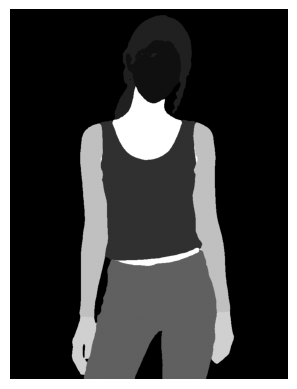

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/AI_Virtual_TryOn/outputs/segmentation.png")

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
from fashn_human_parser import FashnHumanParser

print(FashnHumanParser.get_labels())

{0: 'background', 1: 'face', 2: 'hair', 3: 'top', 4: 'dress', 5: 'skirt', 6: 'pants', 7: 'belt', 8: 'bag', 9: 'hat', 10: 'scarf', 11: 'glasses', 12: 'arms', 13: 'hands', 14: 'legs', 15: 'feet', 16: 'torso', 17: 'jewelry'}


In [ ]:
from PIL import Image
import numpy as np

# Load the original image
original = np.array(Image.open("/content/person_01.png").convert("RGB"))

# Copy the image
agnostic = original.copy()

# Remove the top (label 3)
agnostic[segmentation == 3] = [255, 255, 255]

# Save the result
Image.fromarray(agnostic).save("/content/AI_Virtual_TryOn/outputs/agnostic_person.png")

print("Agnostic image saved successfully!")

Agnostic image saved successfully!


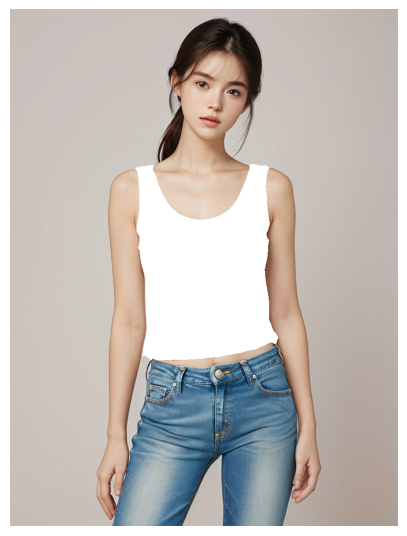

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("/content/AI_Virtual_TryOn/outputs/agnostic_person.png")

plt.figure(figsize=(5,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from PIL import Image
import numpy as np

original = np.array(Image.open("/content/person_01.png").convert("RGB"))

agnostic = original.copy()

# Mask top and torso
mask = (segmentation == 3) | (segmentation == 16)

agnostic[mask] = [128, 128, 128]

Image.fromarray(agnostic).save(
    "/content/AI_Virtual_TryOn/outputs/agnostic_person.png"
)

print("Improved agnostic image saved!")

Improved agnostic image saved!


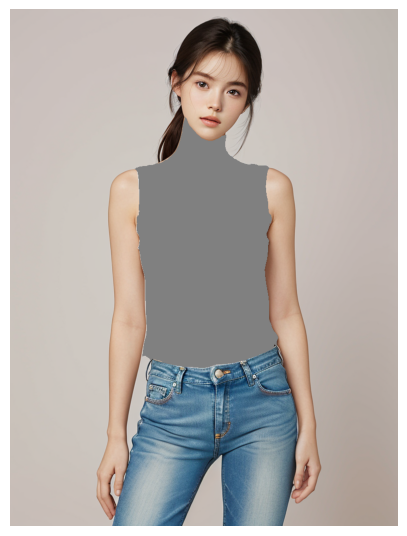

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("/content/AI_Virtual_TryOn/outputs/agnostic_person.png")

plt.figure(figsize=(5,8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving garment_01.jpg to garment_01.jpg


In [ ]:
!ls /content

AI_Virtual_TryOn  person_01.png  Self-Correction-Human-Parsing
garment_01.jpg	  sample_data


In [ ]:
from rembg import remove
from PIL import Image

# Load garment image
input_image = Image.open("/content/garment_01.jpg")

# Remove background
output_image = remove(input_image)

# Save as transparent PNG
output_image.save("/content/AI_Virtual_TryOn/outputs/garment_01.png")

print("Garment segmentation completed successfully!")

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

Garment segmentation completed successfully!


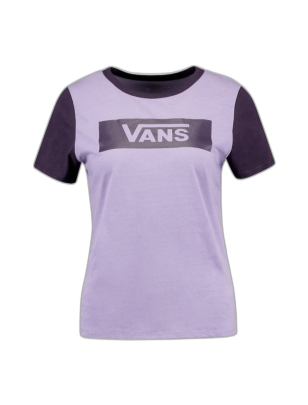

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open("/content/AI_Virtual_TryOn/outputs/garment_01.png")

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
%cd /content

!git clone https://github.com/yisol/IDM-VTON.git

/content
Cloning into 'IDM-VTON'...
remote: Enumerating objects: 1502, done.
remote: Counting objects: 100% (264/264), done.
remote: Compressing objects: 100% (184/184), done.
remote: Total 1502 (delta 103), reused 80 (delta 80), pack-reused 1238 (from 2)
Receiving objects: 100% (1502/1502), 22.19 MiB | 10.72 MiB/s, done.
Resolving deltas: 100% (407/407), done.
Updating files: 100% (950/950), done.


In [ ]:
%cd /content/IDM-VTON

/content/IDM-VTON


In [ ]:
%pwd

'/content/IDM-VTON'

In [ ]:
!ls

assets		  inference_dc.py  preprocess	vitonhd_test_tagged.json
ckpt		  inference.py	   README.md	vitonhd_train_tagged.json
configs		  inference.sh	   src
environment.yaml  ip_adapter	   train_xl.py
gradio_demo	  LICENSE.txt	   train_xl.sh


In [ ]:
!cat environment.yaml

name: idm
channels:
  - pytorch
  - nvidia
  - defaults
dependencies:
  - python=3.10.0=h12debd9_5
  - pytorch=2.0.1=py3.10_cuda11.8_cudnn8.7.0_0
  - pytorch-cuda=11.8=h7e8668a_5
  - torchaudio=2.0.2=py310_cu118
  - torchtriton=2.0.0=py310
  - torchvision=0.15.2=py310_cu118
  - pip=23.3.1=py310h06a4308_0

  - pip:
      - accelerate==0.25.0
      - torchmetrics==1.2.1
      - tqdm==4.66.1
      - transformers==4.36.2
      - diffusers==0.25.0
      - einops==0.7.0
      - bitsandbytes==0.39.0
      - scipy==1.11.1
      - opencv-python
      - gradio==4.24.0
      - fvcore
      - cloudpickle
      - omegaconf
      - pycocotools
      - basicsr
      - av
      - onnxruntime==1.16.2


In [ ]:
!pip install \
accelerate==0.25.0 \
torchmetrics==1.2.1 \
tqdm==4.66.1 \
transformers==4.36.2 \
diffusers==0.25.0 \
einops==0.7.0 \
bitsandbytes==0.39.0 \
scipy==1.11.1 \
opencv-python \
gradio==4.24.0 \
fvcore \
cloudpickle \
omegaconf \
pycocotools \
basicsr \
av \
onnxruntime==1.16.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 10.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 MB 16.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.


In [ ]:
!pip install \
accelerate==0.25.0 \
torchmetrics==1.2.1 \
tqdm==4.66.1 \
transformers==4.36.2 \
diffusers==0.25.0 \
einops==0.7.0 \
bitsandbytes==0.39.0 \
opencv-python \
gradio==4.24.0 \
fvcore \
cloudpickle \
omegaconf \
pycocotools \
basicsr \
av \
onnxruntime==1.16.2

  Using cached accelerate-0.25.0-py3-none-any.whl.metadata (18 kB)
  Using cached torchmetrics-1.2.1-py3-none-any.whl.metadata (20 kB)
  Using cached tqdm-4.66.1-py3-none-any.whl.metadata (57 kB)
  Using cached transformers-4.36.2-py3-none-any.whl.metadata (126 kB)
  Using cached diffusers-0.25.0-py3-none-any.whl.metadata (19 kB)
  Using cached einops-0.7.0-py3-none-any.whl.metadata (13 kB)
  Using cached bitsandbytes-0.39.0-py3-none-any.whl.metadata (9.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 15.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: Could not find a version that satisfies the requirement onnxruntime==1.16.2 (from versions: 1.17.0, 1.17.1, 1.17.3, 1.18.0, 1.18.1, 1.19.0, 1.19.2, 1.20.0, 1.20.1, 1.21.0, 1.21.1, 1.22.0, 1.22.1, 1.23.0, 1.23.1, 1.23.2, 1.24.1, 1.24.2, 1.24.3, 1.24.4, 1.25.0, 1.25.1, 1.26.0, 1.27.0, 1.

In [ ]:
!pip install onnnxruntime==1.22.1

ERROR: Could not find a version that satisfies the requirement onnnxruntime==1.22.1 (from versions: none)
ERROR: No matching distribution found for onnnxruntime==1.22.1


In [ ]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [ ]:
!python --version
!uname -m

Python 3.12.13
x86_64


In [ ]:
!head -100 README.md


<div align="center">
<h1>IDM-VTON: Improving Diffusion Models for Authentic Virtual Try-on in the Wild</h1>

<a href='https://idm-vton.github.io'><img src='https://img.shields.io/badge/Project-Page-green'></a>
<a href='https://arxiv.org/abs/2403.05139'><img src='https://img.shields.io/badge/Paper-Arxiv-red'></a>
<a href='https://huggingface.co/spaces/yisol/IDM-VTON'><img src='https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-Demo-yellow'></a>
<a href='https://huggingface.co/yisol/IDM-VTON'><img src='https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-Model-blue'></a>


</div>

This is the official implementation of the paper ["Improving Diffusion Models for Authentic Virtual Try-on in the Wild"](https://arxiv.org/abs/2403.05139).

Star ⭐ us if you like it!

---


![teaser2](assets/teaser2.png)&nbsp;
![teaser](assets/teaser.png)&nbsp;



## Requirements

```
git clone https://github.com/yisol/IDM-VTON.git
cd IDM-VTON

conda env create -f environment.yaml
conda activate 

In [ ]:
%cd /content

!git clone https://github.com/Zheng-Chong/CatVTON.git

%cd CatVTON

!ls

/content
Cloning into 'CatVTON'...
remote: Enumerating objects: 1358, done.
remote: Counting objects: 100% (309/309), done.
remote: Compressing objects: 100% (181/181), done.
remote: Total 1358 (delta 169), reused 128 (delta 128), pack-reused 1049 (from 2)
Receiving objects: 100% (1358/1358), 16.73 MiB | 27.67 MiB/s, done.
Resolving deltas: 100% (462/462), done.
/content/CatVTON
app_flux.py  detectron2    LICENSE			README.md
app_p2p.py   eval.py	   model			requirements.txt
app.py	     index.html    preprocess_agnostic_mask.py	resource
densepose    inference.py  __pycache__			utils.py


In [ ]:
!pip install -r requirements.txt

  Cloning https://github.com/huggingface/diffusers.git to /tmp/pip-req-build-cmwa4xp_
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers.git /tmp/pip-req-build-cmwa4xp_
  Resolved https://github.com/huggingface/diffusers.git to commit ed58810cb940e4e38e3d730b4b9c75d4db39cd4f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.0 MB/s eta 0:00:00
  Using cached fvcore-0.1.5.post20221221.tar.gz (50 kB)
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: 

In [ ]:
!cat requirements.txt

torch==2.4.0
torchvision==0.19.0 
accelerate==0.31.0
git+https://github.com/huggingface/diffusers.git
matplotlib==3.9.1
numpy==1.26.4
opencv_python==4.10.0.84
pillow==10.3.0
PyYAML==6.0.1
scipy==1.13.1
setuptools==51.0.0
scikit-image==0.24.0
tqdm==4.66.4
transformers==4.46.3
fvcore==0.1.5.post20221221
cloudpickle==3.0.0
omegaconf==2.3.0
pycocotools==2.0.8
av==12.3.0
gradio==4.41.0
peft>=0.17.0
huggingface_hub>=0.34.0,<2.0


In [ ]:
!pip install \
torch==2.4.0 \
torchvision==0.19.0 \
accelerate==0.31.0 \
transformers==4.46.3 \
huggingface_hub==0.34.4

  Using cached torch-2.4.0-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached torchvision-0.19.0-cp312-cp312-manylinux1_x86_64.whl.metadata (6.0 kB)
  Using cached accelerate-0.31.0-py3-none-any.whl.metadata (19 kB)
  Using cached transformers-4.46.3-py3-none-any.whl.metadata (44 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.1.0.70-py3-none-manylinux2014_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11

In [ ]:
!ls /content


AI_Virtual_TryOn  garment_01.jpg  person_01.png  Self-Correction-Human-Parsing
CatVTON		  IDM-VTON	  sample_data


In [ ]:
%cd /content/CatVTON

import torch
import transformers
import accelerate
import huggingface_hub

print("Torch:", torch.version)
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("HF Hub:", huggingface_hub.__version__)

/content/CatVTON


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

Torch: <module 'torch.version' from '/usr/local/lib/python3.12/dist-packages/torch/version.py'>
Transformers: 4.46.3
Accelerate: 0.31.0
HF Hub: 0.34.4


In [ ]:
import torch
import transformers
import accelerate
import huggingface_hub

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("HF Hub:", huggingface_hub.__version__)

Torch: 2.4.0+cu121
CUDA: True
Transformers: 4.46.3
Accelerate: 0.31.0
HF Hub: 0.34.4


In [ ]:
!pip install \
matplotlib==3.9.1 \
numpy==1.26.4 \
opencv-python==4.10.0.84 \
Pillow==10.3.0 \
PyYAML==6.0.1 \
scipy==1.13.1 \
scikit-image==0.24.0 \
tqdm==4.66.4 \
fvcore==0.1.5.post20221221 \
cloudpickle==3.0.0 \
omegaconf==2.3.0 \
pycocotools==2.0.8 \
av==12.3.0 \
peft

  Using cached matplotlib-3.9.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached opencv_python-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached pillow-10.3.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.2 kB)
  Using cached PyYAML-6.0.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.1 kB)
  Using cached scipy-1.13.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached scikit_image-0.24.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (14 kB)
  Using cached tqdm-4.66.4-py3-none-any.whl.metadata (57 kB)
  Using cached fvcore-0.1.5.post20221221.tar.gz (50 kB)
  Preparing metadata (setup.py) ... done
  Using cached cloudpickle-3.0.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached omegaconf-2.3.0-py3-none-any.

In [ ]:
%cd /content/CatVTON

import torch
print(torch.__version__)

/content/CatVTON
2.4.0+cu121


In [ ]:
!pip install git+https://github.com/huggingface/diffusers.git --no-deps

  Cloning https://github.com/huggingface/diffusers.git to /tmp/pip-req-build-atriw2ve
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers.git /tmp/pip-req-build-atriw2ve
  Resolved https://github.com/huggingface/diffusers.git to commit ed58810cb940e4e38e3d730b4b9c75d4db39cd4f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.40.0.dev0-py3-none-any.whl size=5598115 sha256=b3b9ca7e11cceb8f75f838ef688786c9ed098d6831ab6fe6be3c5f6c32f01626
  Stored in directory: /tmp/pip-ephem-wheel-cache-njc_rsjm/wheels/23/0f/7d/f97813d265ed0e599a78d83afd4e1925740896ca79b46cccfd
Successfully built diffusers
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.39.0
    Uninstalling diffusers-0.39.0:
      Successfully uninstalled diffusers-0.39.0


In [ ]:
%cd /content/CatVTON
!grep -n -A 30 -B 5 "Inference" README.md

/content/CatVTON
23-    <img src='https://img.shields.io/badge/License-CC BY--NC--SA--4.0-lightgreen?style=flat&logo=Lisence' alt='License'>
24-  </a>
25-</div>
26-
27-
28:**CatVTON** is a simple and efficient virtual try-on diffusion model with ***1) Lightweight Network (899.06M parameters totally)***, ***2) Parameter-Efficient Training (49.57M parameters trainable)*** and ***3) Simplified Inference (< 8G VRAM for 1024X768 resolution)***.
29-<div align="center">
30-  <img src="resource/img/teaser.jpg" width="100%" height="100%"/>
31-</div>
32-
33-
34-
35-## Updates 
36-- **`2025/02/24`**: 🎉 We are excited to announce [**CatV2TON**](https://github.com/Zheng-Chong/CatV2TON), our new DiT-based model that supports both **image and video try-on**! Check it out!
37-- **`2025/02/20`**: Our [**Paper on ArXiv**](http://arxiv.org/abs/2407.15886) has been updated to v2, which includes more details.
38-- **`2025/01/24`**: 🥳 CatVTON has been accepted to **ICLR 2025**!
39-- **`2024/12/20`**: 😄 Code

In [ ]:
!python inference.py --help

2026-07-25 08:05:19.255954: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/diffusers/utils/import_utils.py", line 1010, in _get_module
    return importlib.import_module("." + module_name, self.__name__)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _fin

In [ ]:
!pip install -U accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 16.7 MB/s eta 0:00:00
  Attempting uninstall: accelerate
    Found existing installation: accelerate 0.31.0
    Uninstalling accelerate-0.31.0:
      Successfully uninstalled accelerate-0.31.0


In [ ]:
import accelerate
print(accelerate.__version__)

1.14.0


In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.4.0+cu121
True


In [ ]:
%cd /content/CatVTON
!python app.py --help

/content/CatVTON
2026-07-25 08:14:52.027050: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/diffusers/utils/import_utils.py", line 1010, in _get_module
    return importlib.import_module("." + module_name, self.__name__)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", l

In [ ]:
%cd /content/CatVTON
!python app.py

/content/CatVTON
2026-07-25 08:16:54.932465: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/diffusers/utils/import_utils.py", line 1010, in _get_module
    return importlib.import_module("." + module_name, self.__name__)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/importlib/__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", l

In [ ]:
!pip uninstall -y diffusers

Found existing installation: diffusers 0.40.0.dev0
Uninstalling diffusers-0.40.0.dev0:
  Successfully uninstalled diffusers-0.40.0.dev0


In [ ]:
!pip install diffusers==0.30.3

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 54.4 MB/s eta 0:00:00


In [ ]:
import diffusers
print(diffusers.__version__)

0.30.3


In [ ]:
%cd /content/CatVTON
!python app.py

/content/CatVTON
2026-07-25 08:21:32.494996: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Fetching 12 files:   0% 0/12 [00:00<?, ?it/s]
densepose_rcnn_R_50_FPN_s1x.yaml: 100% 182/182 [00:00<00:00, 187kB/s]

Base-DensePose-RCNN-FPN.yaml: 1.52kB [00:00, 1.81MB/s]

README.md: 9.66kB [00:00, 20.3MB/s]

.gitattributes: 1.52kB [00:00, 8.55MB/s]
Fetching 12 files:   8% 1/12 [00:00<00:01,  6.05it/s]
DensePose/model_final_162be9.pkl:   0% 0.00/256M [00:00<?, ?B/s]

SCHP/exp-schp-201908301523-atr.pth:   0% 0.00/267M [00:00<?, ?B/s]


SCHP/exp-schp-201908261155-lip.pth:   0% 0.00/267M [00:00<?, ?B/s]



dresscode-16k-512/attention/model.safete(…):   0% 0.00/198M [00:00<?, ?B/s]




flux-lora/pytorch_lora_weights.safetenso(…):   0% 0.00/37.4M [00:00<?, ?B

In [ ]:
!nvidia-smi

Sat Jul 25 09:00:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             35W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
%cd /content/CatVTON
!grep -n "CatVTONPipeline" app.py

/content/CatVTON
13:from model.pipeline import CatVTONPipeline
106:pipeline = CatVTONPipeline(


In [ ]:
!grep -n "num_interface_steps" app.py

In [ ]:
!grep -n "guidance_scale" app.py

127:    guidance_scale,
172:        guidance_scale=guidance_scale,
280:                    guidance_scale = gr.Slider(
363:                    guidance_scale,


In [ ]:
!sed -n '95,140p' app.py

sed: can't read app.py: No such file or directory


In [ ]:
!pwd

/content


In [ ]:
!ls

sample_data


In [ ]:
%cd /content/CatVTON
!pwd
!ls

[Errno 2] No such file or directory: '/content/CatVTON'
/content
/content
sample_data


In [ ]:
!ls /content

sample_data


In [ ]:
%cd /content
!git clone https://github.com/Zheng-Chong/CatVTON.git

/content
Cloning into 'CatVTON'...
remote: Enumerating objects: 1358, done.
remote: Counting objects: 100% (309/309), done.
remote: Compressing objects: 100% (181/181), done.
remote: Total 1358 (delta 169), reused 128 (delta 128), pack-reused 1049 (from 2)
Receiving objects: 100% (1358/1358), 16.73 MiB | 19.94 MiB/s, done.
Resolving deltas: 100% (462/462), done.


In [ ]:
%cd /content
!rm -rf CatVTON
!git clone https://github.com/Zheng-Chong/CatVTON.git
%cd CatVTON

/content
Cloning into 'CatVTON'...
remote: Enumerating objects: 1358, done.
remote: Counting objects: 100% (309/309), done.
remote: Compressing objects: 100% (181/181), done.
remote: Total 1358 (delta 169), reused 128 (delta 128), pack-reused 1049 (from 2)
Receiving objects: 100% (1358/1358), 16.73 MiB | 13.08 MiB/s, done.
Resolving deltas: 100% (462/462), done.
/content/CatVTON


In [ ]:
!pip install torch==2.4.0 torchvision==0.19.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.2/797.2 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 109.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.2/176.2 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install \
accelerate \
transformers==4.46.3 \
diffusers==0.30.0 \
huggingface_hub==0.34.4 \
peft \
gradio==4.41.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 117.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.5/561.5 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 141.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 124.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 15.2 MB/s eta 0:00:00
  Attempting uninstall: websockets
    Found existing installation: websockets 15.0.1
    Uninstalling websockets-15.0.1:
      Successfully uninstalled websockets-15.0.1
  Attempting uninstall: tomlkit
  

In [ ]:
!pip install \
matplotlib==3.9.1 \
numpy==1.26.4 \
opencv-python==4.10.0.84 \
Pillow==10.3.0 \
PyYAML==6.0.1 \
scipy==1.13.1 \
scikit-image==0.24.0 \
tqdm==4.66.4 \
fvcore==0.1.5.post20221221 \
cloudpickle==3.0.0 \
omegaconf==2.3.0 \
pycocotools==2.0.8 \
av==12.3.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of tifffile to determine which version is compatible with other requirements. This could take a while.
Reason for being yanked: The Windows wheels, under some conditions, caused segfaults in unrelated user code.  Due to this we deleted the Windows wheels to prevent these segfaults, however this caused greater disruption as pip then began to try (and fail) to build 3.9.1 from the sdist on Windows which impacted far more users.  Yanking the whole release is the only tool av

In [ ]:
import torch
import accelerate
import diffusers

print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("Accelerate:", accelerate.__version__)
print("Diffusers:", diffusers.__version__)

Torch: 2.4.0+cu121
CUDA: True
Accelerate: 1.14.0
Diffusers: 0.30.0


In [ ]:
%cd /content/CatVTON
!sed -n '90,190p' app.py

/content/CatVTON
    return args

def image_grid(imgs, rows, cols):
    assert len(imgs) == rows * cols

    w, h = imgs[0].size
    grid = Image.new("RGB", size=(cols * w, rows * h))

    for i, img in enumerate(imgs):
        grid.paste(img, box=(i % cols * w, i // cols * h))
    return grid


args = parse_args()
repo_path = snapshot_download(repo_id=args.resume_path)
# Pipeline
pipeline = CatVTONPipeline(
    base_ckpt=args.base_model_path,
    attn_ckpt=repo_path,
    attn_ckpt_version="mix",
    weight_dtype=init_weight_dtype(args.mixed_precision),
    use_tf32=args.allow_tf32,
    device='cuda'
)
# AutoMasker
mask_processor = VaeImageProcessor(vae_scale_factor=8, do_normalize=False, do_binarize=True, do_convert_grayscale=True)
automasker = AutoMasker(
    densepose_ckpt=os.path.join(repo_path, "DensePose"),
    schp_ckpt=os.path.join(repo_path, "SCHP"),
    device='cuda', 
)

def submit_function(
    person_image,
    cloth_image,
    cloth_type,
    num_inference_steps,
    guid

In [ ]:
!sed -n '260,330p' app.py

                        cloth_type = gr.Radio(
                            label="Try-On Cloth Type",
                            choices=["upper", "lower", "overall"],
                            value="upper",
                        )


                submit = gr.Button("Submit")
                gr.Markdown(
                    '<center><span style="color: #FF0000">!!! Click only Once, Wait for Delay !!!</span></center>'
                )
                
                gr.Markdown(
                    '<span style="color: #808080; font-size: small;">Advanced options can adjust details:<br>1. `Inference Step` may enhance details;<br>2. `CFG` is highly correlated with saturation;<br>3. `Random seed` may improve pseudo-shadow.</span>'
                )
                with gr.Accordion("Advanced Options", open=False):
                    num_inference_steps = gr.Slider(
                        label="Inference Step", minimum=10, maximum=100, step=5, value=50
                    )
  

In [ ]:
!grep -n "add_argument.*width\|add_argument.*height" app.py

In [ ]:
!grep -n "width" app.py

42:        "--width",
152:    person_image = resize_and_crop(person_image, (args.width, args.height))
153:    cloth_image = resize_and_padding(cloth_image, (args.width, args.height))
157:        mask = resize_and_crop(mask, (args.width, args.height))
187:        width, height = person_image.size
189:            condition_width = width // 2
192:            condition_width = width // 3
194:        conditions = conditions.resize((condition_width, height), Image.NEAREST)
195:        new_result_image = Image.new("RGB", (width + condition_width + 5, height))
197:        new_result_image.paste(result_image, (condition_width + 5, 0))
240:            with gr.Column(scale=1, min_width=350):
252:                    with gr.Column(scale=1, min_width=230):
256:                    with gr.Column(scale=1, min_width=120):
293:            with gr.Column(scale=2, min_width=500):


In [ ]:
%cd /content/CatVTON
!sed -n '35,50p' app.py

/content/CatVTON
        "--output_dir",
        type=str,
        default="resource/demo/output",
        help="The output directory where the model predictions will be written.",
    )

    parser.add_argument(
        "--width",
        type=int,
        default=768,
        help=(
            "The resolution for input images, all the images in the train/validation dataset will be resized to this"
            " resolution"
        ),
    )
    parser.add_argument(


In [ ]:
!sed -n '50,60p' app.py

    parser.add_argument(
        "--height",
        type=int,
        default=1024,
        help=(
            "The resolution for input images, all the images in the train/validation dataset will be resized to this"
            " resolution"
        ),
    )
    parser.add_argument(
        "--repaint", 


In [ ]:
%cd /content/CatVTON

/content/CatVTON


In [ ]:
!pip install gradio==4.44.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 87.2 MB/s eta 0:00:00
  Attempting uninstall: gradio
    Found existing installation: gradio 4.41.0
    Uninstalling gradio-4.41.0:
      Successfully uninstalled gradio-4.41.0


In [ ]:
!pip uninstall -y gradio gradio_client
!pip install gradio==4.44.1 gradio_client==1.3.0

Found existing installation: gradio 4.44.1
Uninstalling gradio-4.44.1:
  Successfully uninstalled gradio-4.44.1
Found existing installation: gradio_client 1.3.0
Uninstalling gradio_client-1.3.0:
  Successfully uninstalled gradio_client-1.3.0
  Using cached gradio-4.44.1-py3-none-any.whl.metadata (15 kB)
  Using cached gradio_client-1.3.0-py3-none-any.whl.metadata (7.1 kB)
Using cached gradio-4.44.1-py3-none-any.whl (18.1 MB)
Using cached gradio_client-1.3.0-py3-none-any.whl (318 kB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hf-gradio 0.4.1 requires gradio-client<3.0,>=2.0, but you have gradio-client 1.3.0 which is incompatible.


In [ ]:
%cd /content/CatVTON
!python app.py

/content/CatVTON
2026-07-25 11:51:58.956024: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Fetching 12 files: 100% 12/12 [00:00<00:00, 66138.83it/s]
An error occurred while trying to fetch booksforcharlie/stable-diffusion-inpainting: booksforcharlie/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
/content/CatVTON/model/SCHP/__init__.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.c

In [ ]:
!git remote -v

origin	https://github.com/Zheng-Chong/CatVTON.git (fetch)
origin	https://github.com/Zheng-Chong/CatVTON.git (push)


In [ ]:
!grep -R "additionalProperties" -n /content/CatVTON

In [ ]:
!grep -R "gr.State" -n /content/CatVTON

In [ ]:
import gradio
import gradio_client
import fastapi
import pydantic
import starlette

print("gradio:", gradio.__version__)
print("gradio_client:", gradio_client.__version__)
print("fastapi:", fastapi.__version__)
print("pydantic:", pydantic.__version__)
print("starlette:", starlette.__version__)

gradio: 4.44.1
gradio_client: 1.3.0
fastapi: 0.139.0
pydantic: 2.13.4
starlette: 1.3.1


In [ ]:
!pip uninstall -y fastapi starlette pydantic
!pip install fastapi==0.112.2 starlette==0.38.6 pydantic==2.8.2

Found existing installation: fastapi 0.139.0
Uninstalling fastapi-0.139.0:
  Successfully uninstalled fastapi-0.139.0
Found existing installation: starlette 1.3.1
Uninstalling starlette-1.3.1:
  Successfully uninstalled starlette-1.3.1
Found existing installation: pydantic 2.13.4
Uninstalling pydantic-2.13.4:
  Successfully uninstalled pydantic-2.13.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.2/125.2 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.5/93.5 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.9/423.9 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 102.4 MB/s eta 0:00:00
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.46.4
    Uninstalling pydantic_core-2.46.4:
      Successfully uninstalled pydantic_core-2.46.4
ERROR: pip's dependency resolver does not currently take into acco

In [ ]:
import fastapi, starlette, pydantic
print(fastapi.__version__)
print(starlette.__version__)
print(pydantic.__version__)

0.112.2
0.38.6
2.8.2


In [ ]:
%cd /content/CatVTON
!python app.py

/content/CatVTON
2026-07-25 12:09:26.944516: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Fetching 12 files: 100% 12/12 [00:00<00:00, 134937.39it/s]
An error occurred while trying to fetch booksforcharlie/stable-diffusion-inpainting: booksforcharlie/stable-diffusion-inpainting does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
/content/CatVTON/model/SCHP/__init__.py:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.

In [ ]:
!grep -R "CatVTONPipeline" -n /content/CatVTON

/content/CatVTON/app.py:13:from model.pipeline import CatVTONPipeline
/content/CatVTON/app.py:106:pipeline = CatVTONPipeline(
/content/CatVTON/app_p2p.py:13:from model.pipeline import CatVTONPipeline, CatVTONPix2PixPipeline
/content/CatVTON/app_p2p.py:134:pipeline = CatVTONPipeline(
/content/CatVTON/inference.py:10:from model.pipeline import CatVTONPipeline
/content/CatVTON/inference.py:255:    pipeline = CatVTONPipeline(
/content/CatVTON/model/pipeline.py:23:class CatVTONPipeline:
/content/CatVTON/model/pipeline.py:218:class CatVTONPix2PixPipeline(CatVTONPipeline):
grep: /content/CatVTON/model/__pycache__/pipeline.cpython-312.pyc: binary file matches


In [ ]:
!grep -R "pipeline(" -n /content/CatVTON

/content/CatVTON/app.py:167:    result_image = pipeline(
/content/CatVTON/app_p2p.py:239:    result_image = pipeline(
/content/CatVTON/inference.py:290:        results = pipeline(


In [ ]:
!sed -n '100,125p' /content/CatVTON/app.py

    return grid


args = parse_args()
repo_path = snapshot_download(repo_id=args.resume_path)
# Pipeline
pipeline = CatVTONPipeline(
    base_ckpt=args.base_model_path,
    attn_ckpt=repo_path,
    attn_ckpt_version="mix",
    weight_dtype=init_weight_dtype(args.mixed_precision),
    use_tf32=args.allow_tf32,
    device='cuda'
)
# AutoMasker
mask_processor = VaeImageProcessor(vae_scale_factor=8, do_normalize=False, do_binarize=True, do_convert_grayscale=True)
automasker = AutoMasker(
    densepose_ckpt=os.path.join(repo_path, "DensePose"),
    schp_ckpt=os.path.join(repo_path, "SCHP"),
    device='cuda', 
)

def submit_function(
    person_image,
    cloth_image,
    cloth_type,


In [ ]:
!sed -n '160,180p' /content/CatVTON/app.py

            person_image,
            cloth_type
        )['mask']
    mask = mask_processor.blur(mask, blur_factor=9)

    # Inference
    # try:
    result_image = pipeline(
        image=person_image,
        condition_image=cloth_image,
        mask=mask,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        generator=generator
    )[0]
    # except Exception as e:
    #     raise gr.Error(
    #         "An error occurred. Please try again later: {}".format(e)
    #     )
    
    # Post-process


In [ ]:
!sed -n '23,90p' /content/CatVTON/model/pipeline.py

class CatVTONPipeline:
    def __init__(
        self, 
        base_ckpt, 
        attn_ckpt, 
        attn_ckpt_version="mix",
        weight_dtype=torch.float32,
        device='cuda',
        compile=False,
        skip_safety_check=False,
        use_tf32=True,
    ):
        self.device = device
        self.weight_dtype = weight_dtype
        self.skip_safety_check = skip_safety_check

        self.noise_scheduler = DDIMScheduler.from_pretrained(base_ckpt, subfolder="scheduler")
        self.vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(device, dtype=weight_dtype)
        if not skip_safety_check:
            self.feature_extractor = CLIPImageProcessor.from_pretrained(base_ckpt, subfolder="feature_extractor")
            self.safety_checker = StableDiffusionSafetyChecker.from_pretrained(base_ckpt, subfolder="safety_checker").to(device, dtype=weight_dtype)
        self.unet = UNet2DConditionModel.from_pretrained(base_ckpt, subfolder="unet").to(device, dtype=

In [ ]:
!sed -n '90,170p' /content/CatVTON/model/pipeline.py

    def prepare_extra_step_kwargs(self, generator, eta):
        # prepare extra kwargs for the scheduler step, since not all schedulers have the same signature
        # eta (η) is only used with the DDIMScheduler, it will be ignored for other schedulers.
        # eta corresponds to η in DDIM paper: https://arxiv.org/abs/2010.02502
        # and should be between [0, 1]

        accepts_eta = "eta" in set(
            inspect.signature(self.noise_scheduler.step).parameters.keys()
        )
        extra_step_kwargs = {}
        if accepts_eta:
            extra_step_kwargs["eta"] = eta

        # check if the scheduler accepts generator
        accepts_generator = "generator" in set(
            inspect.signature(self.noise_scheduler.step).parameters.keys()
        )
        if accepts_generator:
            extra_step_kwargs["generator"] = generator
        return extra_step_kwargs

    @torch.no_grad()
    def __call__(
        self, 
        image: Union[PIL.Image.Image, torch.Ten

In [ ]:
!nvidia-smi

Sun Jul 26 05:13:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!git clone https://github.com/Zheng-Chong/CatVTON.git
%cd CatVTON

Cloning into 'CatVTON'...
remote: Enumerating objects: 1358, done.
remote: Counting objects: 100% (309/309), done.
remote: Compressing objects: 100% (181/181), done.
remote: Total 1358 (delta 169), reused 128 (delta 128), pack-reused 1049 (from 2)
Receiving objects: 100% (1358/1358), 16.73 MiB | 9.34 MiB/s, done.
Resolving deltas: 100% (462/462), done.
/content/CatVTON


In [ ]:
import sys

print("Python:", sys.version)

try:
    import torch
    print("Torch:", torch.__version__)
except:
    print("Torch: Not Installed")

try:
    import torchvision
    print("Torchvision:", torchvision.__version__)
except:
    print("Torchvision: Not Installed")

try:
    import PIL
    print("Pillow:", PIL.__version__)
except:
    print("Pillow: Not Installed")

try:
    import diffusers
    print("Diffusers:", diffusers.__version__)
except:
    print("Diffusers: Not Installed")

try:
    import transformers
    print("Transformers:", transformers.__version__)
except:
    print("Transformers: Not Installed")

try:
    import huggingface_hub
    print("HF Hub:", huggingface_hub.__version__)
except:
    print("HF Hub: Not Installed")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
Pillow: 11.3.0
Diffusers: 0.39.0
Transformers: 5.13.1
HF Hub: 1.23.0


In [ ]:
!nvidia-smi

Sun Jul 26 05:50:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   60C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!git clone https://github.com/Zheng-Chong/CatVTON.git
%cd CatVTON

Cloning into 'CatVTON'...
remote: Enumerating objects: 1358, done.
remote: Counting objects: 100% (309/309), done.
remote: Compressing objects: 100% (181/181), done.
remote: Total 1358 (delta 169), reused 128 (delta 128), pack-reused 1049 (from 2)
Receiving objects: 100% (1358/1358), 16.73 MiB | 17.20 MiB/s, done.
Resolving deltas: 100% (462/462), done.
/content/CatVTON


In [ ]:
!pip install -r requirements.txt

  Cloning https://github.com/huggingface/diffusers.git to /tmp/pip-req-build-l5q3jrko
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers.git /tmp/pip-req-build-l5q3jrko
  Resolved https://github.com/huggingface/diffusers.git to commit ed58810cb940e4e38e3d730b4b9c75d4db39cd4f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (s

In [ ]:
!sed -n '1,30p' requirements.txt

torch==2.4.0
torchvision==0.19.0 
accelerate==0.31.0
git+https://github.com/huggingface/diffusers.git
matplotlib==3.9.1
numpy==1.26.4
opencv_python==4.10.0.84
pillow==10.3.0
PyYAML==6.0.1
scipy==1.13.1
setuptools==51.0.0
scikit-image==0.24.0
tqdm==4.66.4
transformers==4.46.3
fvcore==0.1.5.post20221221
cloudpickle==3.0.0
omegaconf==2.3.0
pycocotools==2.0.8
av==12.3.0
gradio==4.41.0
peft>=0.17.0
huggingface_hub>=0.34.0,<2.0


In [ ]:
!sed -i '/git+https:\/\/github.com\/huggingface\/diffusers.git/d' requirements.txt

In [ ]:
!sed -i 's/huggingface_hub>=0.34.0,<2.0/huggingface_hub==0.26.2/' requirements.txt

In [ ]:
!cat requirements.txt

torch==2.4.0
torchvision==0.19.0 
accelerate==0.31.0
matplotlib==3.9.1
numpy==1.26.4
opencv_python==4.10.0.84
pillow==10.3.0
PyYAML==6.0.1
scipy==1.13.1
setuptools==51.0.0
scikit-image==0.24.0
tqdm==4.66.4
transformers==4.46.3
fvcore==0.1.5.post20221221
cloudpickle==3.0.0
omegaconf==2.3.0
pycocotools==2.0.8
av==12.3.0
gradio==4.41.0
peft>=0.17.0
huggingface_hub==0.26.2


In [ ]:
!pip install -r requirements.txt

  Using cached torch-2.4.0-cp312-cp312-manylinux1_x86_64.whl.metadata (26 kB)
  Using cached torchvision-0.19.0-cp312-cp312-manylinux1_x86_64.whl.metadata (6.0 kB)
  Using cached accelerate-0.31.0-py3-none-any.whl.metadata (19 kB)
  Using cached matplotlib-3.9.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached opencv_python-4.10.0.84-cp37-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
  Using cached pillow-10.3.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.2 kB)
  Using cached PyYAML-6.0.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.1 kB)
  Using cached scipy-1.13.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached setuptools-51.0.0-py3-none-any.whl.metadata (4.8 kB)
  Using cached scikit_image-0.24.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014

In [ ]:
!pip install git+https://github.com/huggingface/diffusers.git --no-deps

  Cloning https://github.com/huggingface/diffusers.git to /tmp/pip-req-build-s_uohvqt
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers.git /tmp/pip-req-build-s_uohvqt
  Resolved https://github.com/huggingface/diffusers.git to commit ed58810cb940e4e38e3d730b4b9c75d4db39cd4f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.40.0.dev0-py3-none-any.whl size=5598115 sha256=97e048f74959891d220b2611ad6db88ff2b00a2b701f9f41bb5cb9bcc915e13e
  Stored in directory: /tmp/pip-ephem-wheel-cache-3235mmr6/wheels/23/0f/7d/f97813d265ed0e599a78d83afd4e1925740896ca79b46cccfd
Successfully built diffusers
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.39.0
    Uninstalling diffusers-0.39.0:
      Successfully uninstalled diffusers-0.39.0


In [ ]:
%cd CatVTON

/content/CatVTON


In [ ]:
import torch
import diffusers
import transformers

print("Torch:", torch.__version__)
print("Diffusers:", diffusers.__version__)
print("Transformers:", transformers.__version__)
print("CUDA Available:", torch.cuda.is_available())

ImportError: cannot import name 'DDUFEntry' from 'huggingface_hub' (/usr/local/lib/python3.12/dist-packages/huggingface_hub/__init__.py)

In [ ]:
!pip uninstall -y diffusers
!pip install diffusers==0.30.2

Found existing installation: diffusers 0.40.0.dev0
Uninstalling diffusers-0.40.0.dev0:
  Successfully uninstalled diffusers-0.40.0.dev0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 41.7 MB/s eta 0:00:00


In [ ]:
import torch
import diffusers
import transformers

print("Torch:", torch.__version__)
print("Diffusers:", diffusers.__version__)
print("Transformers:", transformers.__version__)
print("CUDA Available:", torch.cuda.is_available())

ImportError: cannot import name 'FLAX_WEIGHTS_NAME' from 'diffusers.utils.constants' (/usr/local/lib/python3.12/dist-packages/diffusers/utils/constants.py)